# Surrogate Impact on Quantum Circuit Synthesis with Evolutionary Algorithms

## Set up Dependencies

In [82]:
import json
import numpy as np
import os
from pprint import pprint
import scipy
from statistics import mean, stdev
from typing import List, Dict, Callable


In [83]:
from tqdm.notebook import tqdm

In [84]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.

In [85]:
import pandas as pd

## Util Functions

In [86]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [87]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [88]:
from dataclasses import dataclass


@dataclass
class Experiment:
    model: str
    qubit_num: int
    gate_count: int

    parent_count: int
    offspring_count: int
    max_evaluations: int
    evaluate_every: int

    source_paths: List[str]
    seeds: List[int]

    tag: str
    data_per_seed: List[pd.DataFrame]
    data_by_generation: pd.DataFrame
    data_by_timestamp: pd.DataFrame
    data_by_evaluations: pd.DataFrame

    def __hash__(self) -> str:
        key = f"{self.qubit_num}_{self.gate_count}_{self.model}_"
        key += f"{self.parent_count}_{self.offspring_count}_"
        key += f"{self.max_evaluations}_{self.evaluate_every}"
        # key += f"{self.tag}t"
        return hash(key)

    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()

    @property
    def config(self):
        return {
            "model": self.model,
            "qubit_num": self.qubit_num,
            "gate_count": self.gate_count,
            "parent_count": self.parent_count,
            "offspring_count": self.offspring_count,
            "max_evaluations": self.max_evaluations,
            "tag": self.tag,
            "evaluate_every": self.evaluate_every,
            "seeds": sorted(self.seeds)
        }

In [89]:
def filter_experiments(experiments: List[Experiment], filter_params: Dict, sort_by: str = "qubit_num") -> List[Experiment]:

    filtered_experiments: List[Experiment] = []
    for experiment in experiments:

        for key, value in filter_params.items():
            
            if experiment.config[key] != value:
                break 

        else:
            filtered_experiments.append(experiment)                 


    filtered_experiments.sort(key=lambda item: item.config[sort_by])
    return filtered_experiments

In [90]:
def sort_by_model(experiments: List[Experiment]) -> None:
    experiment_models = [
        experiment.model for experiment in experiments]

    if None in experiment_models:
        no_model_index = experiment_models.index(None)
        no_model_experiment = experiments.pop(no_model_index)

    experiments.sort(key=lambda experiment: experiment.model)

    if None in experiment_models:
        experiments.insert(0, no_model_experiment)

In [91]:
def load_experiments(results_dir: str = "results", min_evaluations: int = None) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        if not file_name.endswith("_config.json"):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        logging_prefix: str = config["params"]["logging_prefix"]

        data_path = logging_prefix + "_results.csv"

        try:
            experiment_data = pd.read_csv(data_path, delimiter=";")
        except FileNotFoundError:
            print(f"Could not find file at '{data_path}'. Skipping.")

        for column in experiment_data.columns:
            experiment_data = experiment_data.rename(columns={
                column: column.strip().replace(" ", "_")
            })
        enhance_data(experiment_data)

        experiment = Experiment(
            model=config["params"]["surrogate"]["type"] if "type" in config["params"]["surrogate"] else None,
            qubit_num=config["params"]["ea"]["qubit_num"],
            gate_count=config["params"]["ea"]["gate_count"],

            parent_count=config["params"]["ea"]["parent_count"],
            offspring_count=config["params"]["ea"]["offspring_count"],
            max_evaluations=config["params"]["ea"]["max_evaluations"],
            evaluate_every=config["params"]["ea"]["evaluate_every"],

            tag=config["params"]["tag"],

            source_paths=[
                config_path
            ],

            seeds=[
                config["params"]["seed"]
            ],

            data_per_seed=[experiment_data],
            data_by_generation=None,
            data_by_timestamp=None,
            data_by_evaluations=None,
        )

        if experiment in experiments and experiment.seeds[0] in experiments[experiment].seeds:
            print(
                f"Excluding data of {experiment.source_paths[0]} due to seed duplication.")
            
        elif experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].data_per_seed.append(
                experiment.data_per_seed[0])
            
        else:
            experiments[experiment] = experiment

    return experiments

In [92]:
def merge_seed_runs(experiments: List[Experiment], target_evaluations: int = None, apply_timestamp_merging: bool = True, apply_evaluations_merging: bool = True) -> None:
    all_seeds = []

    for experiment in experiments:
        seeds = experiment.seeds
        data_dfs = experiment.data_per_seed

        if target_evaluations is None:
            target_evaluations = experiment.max_evaluations

        seeds_to_remove = []
        for seed, seed_df in zip(seeds, data_dfs):
            # Remove entries that due not reach target.
            if max(seed_df["cum_explicit_evaluations"]) < target_evaluations:
                seeds_to_remove.append(seed)

        seeds = [seed for seed in seeds if seed not in seeds_to_remove]
        all_seeds.extend(seeds)

    unique_seeds = list(set(all_seeds))

    seeds_to_keep = []
    seeds_to_discard = []
    for seed in unique_seeds:
        if all_seeds.count(seed) == len(experiments):
            seeds_to_keep.append(seed)
        else:
            seeds_to_discard.append(seed)


    print(f"Merging results for seeds {seeds_to_keep}")
    for seed in seeds_to_discard:
        print(f"Discarding seed '{seed}'. Only occurred in {all_seeds.count(seed)}/{len(experiments)} experiments.")

    if len(seeds_to_keep) <= 1:
        raise ValueError()

    for experiment in tqdm(experiments, desc="Experiments", leave=False):

        seed_dfs = [
            df for (seed, df) in zip(experiment.seeds, experiment.data_per_seed) if seed in seeds_to_keep
        ]

        # Shorten entries that go beyond target.
        if target_evaluations is not None:
            for i, seed_df in enumerate(seed_dfs):
                seed_dfs[i] = seed_df[seed_df["cum_explicit_evaluations"] <= target_evaluations]

        experiment.data_by_generation = merge_by_generation(
            seed_dfs)

        if apply_timestamp_merging:
            experiment.data_by_timestamp = merge_by_timestamp(
                seed_dfs)

        if apply_evaluations_merging:
            experiment.data_by_evaluations = merge_by_evaluations(
                seed_dfs) 

In [93]:
def enhance_data(df: pd.DataFrame):
    df["cum_duration"] = df["total_duration"].cumsum()

In [94]:
def merge_by_generation(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    min_generations = min([
        max(df["generation"]) for df in dfs
    ])

    for i in range(len(dfs)):
        dfs[i] = dfs[i][dfs[i]["generation"] <= min_generations]

    total_df = pd.concat(dfs)

    grouped_fitness = total_df.groupby("generation")["fitness_best"]
    mean_best_fitness = grouped_fitness.mean()
    median_best_fitness = grouped_fitness.median()
    stdev_best_fitness = grouped_fitness.std()

    grouped_ea_duration = total_df.groupby("generation")["ea_duration"]
    mean_ea_duration = grouped_ea_duration.mean()
    median_ea_duration = grouped_ea_duration.median()
    stdev_ea_duration = grouped_ea_duration.std()

    grouped_eval_duration = total_df.groupby("generation")["eval_duration"]
    mean_eval_duration = grouped_eval_duration.mean()
    median_eval_duration = grouped_eval_duration.median()
    stdev_eval_duration = grouped_eval_duration.std()

    grouped_train_duration = total_df.groupby("generation")["train_duration"]
    mean_train_duration = grouped_train_duration.mean()
    median_train_duration = grouped_train_duration.median()
    stdev_train_duration = grouped_train_duration.std()

    grouped_pred_duration = total_df.groupby("generation")["pred_duration"]
    mean_pred_duration = grouped_pred_duration.mean()
    median_pred_duration = grouped_pred_duration.median()
    stdev_pred_duration = grouped_pred_duration.std()

    grouped_total_duration = total_df.groupby("generation")["total_duration"]
    mean_total_duration = grouped_total_duration.mean()
    median_total_duration = grouped_total_duration.median()
    stdev_total_duration = grouped_total_duration.std()

    total_df["ea_memory"] = pd.to_numeric(
        total_df["ea_memory"], errors="coerce")
    grouped_ea_memory = total_df.groupby("generation")["ea_memory"]
    mean_ea_memory = grouped_ea_memory.mean()
    median_ea_memory = grouped_ea_memory.median()
    stdev_ea_memory = grouped_ea_memory.std()

    total_df["eval_memory"] = pd.to_numeric(
        total_df["eval_memory"], errors="coerce")
    grouped_eval_memory = total_df.groupby("generation")["eval_memory"]
    mean_eval_memory = grouped_eval_memory.mean()
    median_eval_memory = grouped_eval_memory.median()
    stdev_eval_memory = grouped_eval_memory.std()

    total_df["train_memory"] = pd.to_numeric(
        total_df["train_memory"], errors="coerce")
    grouped_train_memory = total_df.groupby("generation")["train_memory"]
    mean_train_memory = grouped_train_memory.mean()
    median_train_memory = grouped_train_memory.median()
    stdev_train_memory = grouped_train_memory.std()

    total_df["pred_memory"] = pd.to_numeric(
        total_df["pred_memory"], errors="coerce")
    grouped_pred_memory = total_df.groupby("generation")["pred_memory"]
    mean_pred_memory = grouped_pred_memory.mean()
    median_pred_memory = grouped_pred_memory.median()
    stdev_pred_memory = grouped_pred_memory.std()

    grouped_max_memory = total_df.groupby("generation")["max_memory"]
    mean_max_memory = grouped_max_memory.mean()
    median_max_memory = grouped_max_memory.median()
    stdev_max_memory = grouped_max_memory.std()

    # Parse columns that might have nan values
    total_df["fitness_mse"] = pd.to_numeric(
        total_df["fitness_mse"], errors="coerce")
    grouped_fitness_mse = total_df.groupby("generation")["fitness_mse"]
    mean_fitness_mse = grouped_fitness_mse.mean()
    median_fitness_mse = grouped_fitness_mse.median()
    stdev_fitness_mse = grouped_fitness_mse.std()

    # Parse columns that might have nan values
    total_df["rank_correlation"] = pd.to_numeric(
        total_df["rank_correlation"], errors="coerce")
    grouped_rank_correlation = total_df.groupby("generation")[
        "rank_correlation"]
    mean_rank_correlation = grouped_rank_correlation.mean()
    median_rank_correlation = grouped_rank_correlation.median()
    stdev_rank_correlation = grouped_rank_correlation.std()

    # Parse columns that might have nan values
    total_df["rank_correlation_new_circuits"] = pd.to_numeric(
        total_df["rank_correlation_new_circuits"], errors="coerce")
    grouped_rank_correlation_new_circuits = total_df.groupby("generation")[
        "rank_correlation_new_circuits"]
    mean_rank_correlation_new_circuits = grouped_rank_correlation_new_circuits.mean()
    median_rank_correlation_new_circuits = grouped_rank_correlation_new_circuits.median()
    stdev_rank_correlation_new_circuits = grouped_rank_correlation_new_circuits.std()

    # Parse columns that might have nan values
    total_df["selection_overlap"] = pd.to_numeric(
        total_df["selection_overlap"], errors="coerce")
    grouped_selection_overlap = total_df.groupby("generation")[
        "selection_overlap"]
    mean_selection_overlap = grouped_selection_overlap.mean()
    median_selection_overlap = grouped_selection_overlap.median()
    stdev_selection_overlap = grouped_selection_overlap.std()

    # Parse columns that might have nan values
    total_df["survival_rate"] = pd.to_numeric(
        total_df["survival_rate"], errors="coerce")
    grouped_survival_rate = total_df.groupby("generation")["survival_rate"]
    mean_survival_rate = grouped_survival_rate.mean()
    median_survival_rate = grouped_survival_rate.median()
    stdev_survival_rate = grouped_survival_rate.std()

    # Parse columns that might have nan values
    total_df["population_diversity"] = pd.to_numeric(
        total_df["population_diversity"], errors="coerce")
    grouped_population_diversity = total_df.groupby(
        "generation")["population_diversity"]
    mean_population_diversity = grouped_population_diversity.mean()
    median_population_diversity = grouped_population_diversity.median()
    stdev_population_diversity = grouped_population_diversity.std()

    grouped_explicit_evaluations = total_df.groupby(
        "generation")["explicit_evaluations"]
    mean_explicit_evaluations = grouped_explicit_evaluations.mean()
    median_explicit_evaluations = grouped_explicit_evaluations.median()
    stdev_explicit_evaluations = grouped_explicit_evaluations.std()

    merged_df = pd.concat(
        [
            mean_best_fitness, median_best_fitness, stdev_best_fitness,
            mean_ea_duration, median_ea_duration, stdev_ea_duration,
            mean_eval_duration, median_eval_duration, stdev_eval_duration,
            mean_train_duration, median_train_duration, stdev_train_duration,
            mean_pred_duration, median_pred_duration, stdev_pred_duration,
            mean_total_duration, median_total_duration, stdev_total_duration,
            mean_ea_memory, median_ea_memory, stdev_ea_memory,
            mean_eval_memory, median_eval_memory, stdev_eval_memory,
            mean_train_memory, median_train_memory, stdev_train_memory,
            mean_pred_memory, median_pred_memory, stdev_pred_memory,
            mean_max_memory, median_max_memory, stdev_max_memory,
            mean_fitness_mse, median_fitness_mse, stdev_fitness_mse,
            mean_rank_correlation, median_rank_correlation, stdev_rank_correlation,
            mean_rank_correlation_new_circuits, median_rank_correlation_new_circuits, stdev_rank_correlation_new_circuits,
            mean_selection_overlap, median_selection_overlap, stdev_selection_overlap,
            mean_survival_rate, median_survival_rate, stdev_survival_rate,
            mean_population_diversity, median_population_diversity, stdev_population_diversity,
            mean_explicit_evaluations, median_explicit_evaluations, stdev_explicit_evaluations
        ], keys=[
            "mean_best_fitness", "median_best_fitness", "stdev_best_fitness",
            "mean_ea_duration", "median_ea_duration", "stdev_ea_duration",
            "mean_eval_duration", "median_eval_duration", "stdev_eval_duration",
            "mean_train_duration", "median_train_duration", "stdev_train_duration",
            "mean_pred_duration", "median_pred_duration", "stdev_pred_duration",
            "mean_total_duration", "median_total_duration", "stdev_total_duration",
            "mean_ea_memory", "median_ea_memory", "stdev_ea_memory",
            "mean_eval_memory", "median_eval_memory", "stdev_eval_memory",
            "mean_train_memory", "median_train_memory", "stdev_train_memory",
            "mean_pred_memory", "median_pred_memory", "stdev_pred_memory",
            "mean_max_memory", "median_max_memory", "stdev_max_memory",
            "mean_fitness_mse", "median_fitness_mse", "stdev_fitness_mse",
            "mean_rank_correlation", "median_rank_correlation", "stdev_rank_correlation",
            "mean_rank_correlation_new_circuits", "median_rank_correlation_new_circuits", "stdev_rank_correlation_new_circuits",
            "mean_selection_overlap", "median_selection_overlap", "stdev_selection_overlap",
            "mean_survival_rate", "median_survival_rate", "stdev_survival_rate",
            "mean_population_diversity", "median_population_diversity", "stdev_population_diversity",
            "mean_explicit_evaluations", "median_explicit_evaluations", "stdev_explicit_evaluations"
        ], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

In [95]:
def merge_by_timestamp(dfs: List[pd.DataFrame]) -> pd.DataFrame:

    # Create a copy for each df to avoid sideeffects based
    # on the upcoming in place modifications of these dfs.
    dfs = [df.copy() for df in dfs]

    unique_cum_durations = pd.concat(
        dfs)["cum_duration"].sort_values().unique()

    for i, df in tqdm(enumerate(dfs), desc="Merge by timestamp", total=len(dfs), leave=False):

        index = 0
        df_data = []

        min_cum_duration = df["cum_duration"].min()
        max_cum_duration = df["cum_duration"].max()

        for cum_duration in unique_cum_durations:

            if cum_duration < min_cum_duration:
                new_row = df.iloc[0].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

            elif cum_duration > max_cum_duration:
                new_row = df.iloc[-1].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

            else:

                if index + 1 < len(df) and df.iloc[index + 1]["cum_duration"] <= cum_duration:
                    index += 1

                new_row = df.iloc[index].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

        dfs[i] = pd.DataFrame(
            df_data, columns=df.columns
        )

    total_df = pd.concat(dfs)

    mean_best_fitness = total_df.groupby("cum_duration")["fitness_best"].mean()
    median_best_fitness = total_df.groupby(
        "cum_duration")["fitness_best"].median()
    stdev_best_fitness = total_df.groupby("cum_duration")["fitness_best"].std()

    merged_df = pd.concat(
        [mean_best_fitness, median_best_fitness, stdev_best_fitness], keys=["mean_best_fitness", "median_best_fitness", "stdev_best_fitness"], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

In [96]:
def merge_by_evaluations(dfs: List[pd.DataFrame]) -> pd.DataFrame:

    # Create a copy for each df to avoid sideeffects based
    # on the upcoming in place modifications of these dfs.
    dfs = [df.copy() for df in dfs]

    unique_cum_evaluations = pd.concat(
        dfs)["cum_explicit_evaluations"].sort_values().unique()

    for i, df in tqdm(enumerate(dfs), desc="Merge by evaluation", total=len(dfs), leave=False):

        index = 0
        df_data = []

        min_cum_evaluation = df["cum_explicit_evaluations"].min()
        max_cum_evaluation = df["cum_explicit_evaluations"].max()

        for cum_evaluation in unique_cum_evaluations:

            if cum_evaluation < min_cum_evaluation:
                new_row = df.iloc[0].copy()
                new_row["cum_explicit_evaluations"] = cum_evaluation

                df_data.append(
                    new_row
                )

            elif cum_evaluation > max_cum_evaluation:
                new_row = df.iloc[-1].copy()
                new_row["cum_explicit_evaluations"] = cum_evaluation

                df_data.append(
                    new_row
                )

            else:

                if index + 1 < len(df) and df.iloc[index + 1]["cum_explicit_evaluations"] <= cum_evaluation:
                    index += 1

                new_row = df.iloc[index].copy()
                new_row["cum_explicit_evaluations"] = cum_evaluation

                df_data.append(
                    new_row
                )

        dfs[i] = pd.DataFrame(
            df_data, columns=df.columns
        )

    total_df = pd.concat(dfs)

    mean_best_fitness = total_df.groupby("cum_explicit_evaluations")[
        "fitness_best"].mean()
    median_best_fitness = total_df.groupby(
        "cum_explicit_evaluations")["fitness_best"].median()
    stdev_best_fitness = total_df.groupby("cum_explicit_evaluations")[
        "fitness_best"].std()

    # Parse columns that might have nan values
    total_df["population_diversity"] = pd.to_numeric(
        total_df["population_diversity"], errors="coerce")
    grouped_population_diversity = total_df.groupby(
        "cum_explicit_evaluations")["population_diversity"]
    mean_population_diversity = grouped_population_diversity.mean()
    median_population_diversity = grouped_population_diversity.median()
    stdev_population_diversity = grouped_population_diversity.std()

    merged_df = pd.concat(
        [mean_best_fitness, median_best_fitness, stdev_best_fitness,
         mean_population_diversity, median_population_diversity, stdev_population_diversity
         ], keys=["mean_best_fitness", "median_best_fitness", "stdev_best_fitness",
                  "mean_population_diversity", "median_population_diversity", "stdev_population_diversity"], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

## Analysis Functions

### Search Performance

In [97]:
def plot_fitness_per_timestamp(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_cum_duration: float = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_timestamp

        if max_cum_duration is not None:
            df = df[df["cum_duration"] <= max_cum_duration]

        ax.plot(df["cum_duration"], df["mean_best_fitness"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["mean_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["cum_duration"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("time (in sec.)")

    ax.set_ylabel("best fitness")

    plt.grid()

    if len(experiments) > 1:
        plt.legend(framealpha=0.5)

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [98]:
def plot_fitness_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_best_fitness"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["mean_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("best fitness")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend(framealpha=0.5)

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [99]:
def plot_fitness_per_seed(experiment: Experiment, target_path: str = None, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    seed_df_tuples = list(zip(experiment.seeds, experiment.data_per_seed))
    seed_df_tuples.sort(key=lambda item: item[0])

    for seed, df in seed_df_tuples:
        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["fitness_best"], label=f"seed: {seed}", linewidth=1)

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("best fitness")

    plt.grid()
    plt.legend(framealpha=0.5)

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [100]:
def plot_fitness_per_evaluations(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_evaluations

        if max_evaluations is not None:
            df = df[df["cum_explicit_evaluations"] <= max_evaluations]

        ax.plot(df["cum_explicit_evaluations"], df["mean_best_fitness"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["mean_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["cum_explicit_evaluations"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("explicit evaluations")

    ax.set_ylabel("best fitness")

    plt.grid()

    if len(experiments) > 1:
        plt.legend(framealpha=0.5)

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [101]:
def create_per_seed_latex_table(experiments: List[Experiment], baseline: Experiment, target_path: str, epsilon: float = 0.01, apply_time_cutoff: bool = True) -> None:
    with open(target_path, "w") as target_file:
        lines = [
            r"\begin{table}[h!]" + "\n",
            r"\begin{tabular}{|| c | c | c | c ||} " + "\n",
            r"\hline" + "\n",
            r"Surrogate Model & Better than Baseline & Tied with Baseline & Successful Runs \\ [0.5ex]" + "\n",
            r"\hline" + "\n"
        ]

        for experiment in experiments:
            seed_count = len(experiment.seeds)

            successful_runs = 0
            
            victories = 0
            ties = 0
    
            for seed, df in zip(experiment.seeds, experiment.data_per_seed):

                if df["cum_explicit_evaluations"].max() < experiment.max_evaluations:
                    seed_count -= 1
                    continue
    
                try: 
                    baseline_idx = baseline.seeds.index(seed)
                    baseline_df = baseline.data_per_seed[baseline_idx]

                    if apply_time_cutoff:
                        time_cutoff = baseline_df["cum_duration"].max()
                        df = df[df["cum_duration"] <= time_cutoff]

                    if df["fitness_best"].min() < epsilon:
                        successful_runs += 1
    
                    if baseline_df["fitness_best"].min() > df["fitness_best"].min():
                        victories += 1
                    elif baseline_df["fitness_best"].min() == df["fitness_best"].min():
                        ties += 1
    
                except ValueError:
                    print(f"No match found for seed {seed}")

            lines.append(
                f"{experiment.model} & ${victories}/{seed_count}$ (${round(victories / seed_count * 100)}\\%$) & ${ties}/{seed_count}$ (${round(ties / seed_count * 100)}\\%$) & ${successful_runs}/{seed_count}$ (${round(successful_runs / seed_count * 100)}\\%$) \\\\" + "\n"
            )

        lines.extend([
            r"\hline" + "\n",
            r"\end{tabular}" + "\n",
            f"\\caption{{Per seed results of different surrogate models on ${baseline.qubit_num}$ qubits and ${baseline.gate_count}$ gates.}}" + "\n",
            f"\\label{{tab:{baseline.qubit_num}q{baseline.gate_count}g_per_seed}}" + "\n",
            r"\end{table}"
        ])

        target_file.writelines(lines)

In [102]:
def print_per_seed_results(experiments: List[Experiment], labels: List[str], baseline: Experiment, epsilon: float = 0.01, apply_time_cutoff: bool = True) -> None:

    print("Per seed performance per experiment:")

    for experiment, label in zip(experiments, labels):
        seed_count = len(experiment.seeds)

        successful_runs = 0

        victories = 0
        ties = 0

        for seed, df in zip(experiment.seeds, experiment.data_per_seed):

            if df["cum_explicit_evaluations"].max() < experiment.max_evaluations:
                seed_count -= 1
                continue

            try:
                baseline_idx = baseline.seeds.index(seed)
                baseline_df = baseline.data_per_seed[baseline_idx]

                if apply_time_cutoff:
                    time_cutoff = baseline_df["cum_duration"].max()
                    df = df[df["cum_duration"] <= time_cutoff]

                if df["fitness_best"].min() < epsilon:
                    successful_runs += 1

                if baseline_df["fitness_best"].min() > df["fitness_best"].min():
                    victories += 1
                elif baseline_df["fitness_best"].min() == df["fitness_best"].min():
                    ties += 1

            except ValueError:
                print(f"No match found for seed {seed}")

        print(f"\n\t'{label}' outperformed on {victories}/{seed_count} seeds ({round(victories / seed_count * 100)}%), tied on {ties}/{seed_count} ({round(ties / seed_count * 100)}%)")
        print(
            f"\t\tfound a good approximation in {successful_runs}/{seed_count} runs ({round(successful_runs / seed_count * 100)}%)")

    print("")

### Surrogate Quality

In [103]:
def plot_rank_correlation_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, max_generations: int = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        if min_evaluations is not None:
            df = df[df["explicit_evaluations"] >= min_evaluations]


        df = df[~df["mean_rank_correlation"].isna()]

        ax.plot(df["generation"], df["mean_rank_correlation"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_rank_correlation"] - df["stdev_rank_correlation"]
            upper_bound = df["mean_rank_correlation"] + df["stdev_rank_correlation"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_xlabel("generation")

    ax.set_ylabel("rank correlation")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [104]:
def plot_rank_correlations(experiments: List[Experiment], labels: List[str], target_path: str = None, min_evaluations: int = None, only_new_circuits: bool = False) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)

        if min_evaluations is not None:
            total_df = total_df[total_df["explicit_evaluations"] >= min_evaluations]


        if only_new_circuits:
            rank_correlations = total_df["rank_correlation_new_circuits"]
        else:
            rank_correlations = total_df["rank_correlation"]

        rank_correlations = pd.to_numeric(rank_correlations, errors="coerce")
        rank_correlations = rank_correlations.dropna()
        data.append(rank_correlations)

    ax.boxplot(data)
    ax.set_ylabel("rank correlation")

    plt.xticks([i + 1 for i in range(len(experiments))], labels, rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [105]:
def plot_selection_overlap_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, max_generations: int = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        if min_evaluations is not None:
            df = df[df["explicit_evaluations"] >= min_evaluations]


        df = df[~df["mean_selection_overlap"].isna()]

        ax.plot(df["generation"], df["mean_selection_overlap"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_selection_overlap"] - df["stdev_selection_overlap"]
            upper_bound = df["mean_selection_overlap"] + df["stdev_selection_overlap"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_xlabel("generation")

    ax.set_ylabel("selection overlap")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [106]:
def plot_selection_overlaps(experiments: List[Experiment], labels: List[str], target_path: str = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)

        if min_evaluations is not None:
             total_df = total_df[total_df["explicit_evaluations"] >= min_evaluations]

        selection_overlaps = total_df["selection_overlap"]
        selection_overlaps = pd.to_numeric(selection_overlaps, errors="coerce")
        selection_overlaps = selection_overlaps.dropna()
        data.append(selection_overlaps)

    ax.boxplot(data)
    ax.set_ylabel("selection overlap")

    plt.xticks([i + 1 for i in range(len(experiments))], labels, rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [107]:
def plot_mse_scores_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, max_generations: int = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        if min_evaluations is not None:
            df = df[df["explicit_evaluations"] >= min_evaluations]

        df = df[~df["mean_fitness_mse"].isna()]

        ax.plot(df["generation"], df["mean_fitness_mse"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_fitness_mse"] - df["stdev_fitness_mse"]
            upper_bound = df["mean_fitness_mse"] + df["stdev_fitness_mse"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_xlabel("generation")

    ax.set_ylabel("fitness mse")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [108]:
def plot_fitness_mse_scores(experiments: List[Experiment], labels: List[str], target_path: str = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):

        total_df = pd.concat(experiment.data_per_seed)

        if min_evaluations is not None:
            total_df = total_df[total_df["explicit_evaluations"]
                                >= min_evaluations]

        mse_scores = total_df["fitness_mse"]
        mse_scores = pd.to_numeric(mse_scores, errors="coerce")
        mse_scores = mse_scores.dropna()
        data.append(mse_scores)

    ax.boxplot(data)
    ax.set_ylabel("fitness mse")

    plt.xticks([i + 1 for i in range(len(experiments))], labels, rotation=45)
    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

### Population Change

In [109]:
def plot_evaluations_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        # exclude first generation due to special treatment for surrogate training.
        df = df[df["generation"] != 0] 
        df = df[df["generation"] % experiment.evaluate_every == 0]

        ax.plot(df["generation"], df["mean_explicit_evaluations"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_explicit_evaluations"] - df["stdev_explicit_evaluations"]
            upper_bound = df["mean_explicit_evaluations"] + df["stdev_explicit_evaluations"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("explicit evaluations")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [110]:
def plot_population_diversity(experiments: List[Experiment], labels: List[str], target_path: str = None, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)
        population_diversity = total_df["population_diversity"]
        population_diversity = pd.to_numeric(population_diversity, errors="coerce")
        population_diversity = population_diversity.dropna()
        data.append(population_diversity)

    ax.boxplot(data)
    ax.set_ylabel("population diversity")

    if anchor_yaxis:
        ax.set_ylim(0)

    plt.xticks([i + 1 for i in range(len(experiments))], labels, rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [111]:
def plot_survival_rate_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_survival_rate"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_survival_rate"] - df["stdev_survival_rate"]
            upper_bound = df["mean_survival_rate"] + df["stdev_survival_rate"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("survival rate")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [112]:
def plot_population_diversity_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_population_diversity"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_population_diversity"] - df["stdev_population_diversity"]
            upper_bound = df["mean_population_diversity"] + df["stdev_population_diversity"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("population diversity")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [113]:
def plot_population_diversity_per_evaluation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_evaluations

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["cum_explicit_evaluations"], df["mean_population_diversity"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_population_diversity"] - df["stdev_population_diversity"]
            upper_bound = df["mean_population_diversity"] + df["stdev_population_diversity"]
            ax.fill_between(
                df["cum_explicit_evaluations"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("explicit evaluations")

    ax.set_ylabel("population diversity")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

### Computational Resources

In [114]:
def plot_duration_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_total_duration"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_total_duration"] - \
                df["stdev_total_duration"]
            upper_bound = df["mean_total_duration"] + \
                df["stdev_total_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("duration (in sec.)")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [115]:
def plot_max_memory_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_max_memory"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_max_memory"] - df["stdev_max_memory"]
            upper_bound = df["mean_max_memory"] + df["stdev_max_memory"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("max memory (in bytes)")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [116]:
def plot_duration(experiments: List[Experiment], labels: List[str], target_path: str = None, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)
        durations = total_df["total_duration"]
        data.append(durations)

    ax.boxplot(data)
    ax.set_ylabel("time per generation (in sec.)")

    if anchor_yaxis:
        ax.set_ylim(0)

    plt.xticks([i + 1 for i in range(len(experiments))], [str(experiment.model) for experiment in experiments], rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [117]:
def plot_duration_stacked(experiments: List[Experiment], labels: List[str], target_path: str = None, relative: bool = False, generations="all") -> None:
    assert generations in ["all", "evaluated", "not_evaluated"]

    ax = plt.subplot()

    weight_by_category = {
        "ea": [],
        "eval": [],
        "train": [],
        "pred": []
    }

    for experiment, label in zip(experiments, labels):

        df = experiment.data_by_generation

        if generations == "evaluated":
            df = df[df["generation"] % experiment.evaluate_every == 0]
            
        elif generations == "not_evaluated":
            df = df[df["generation"] % experiment.evaluate_every != 0]

        ea_duration = df["mean_ea_duration"].sum() / len(df)
        eval_duration = df["mean_eval_duration"].sum() / len(df)
        train_duration = df["mean_train_duration"].sum() / len(df)
        pred_duration = df["mean_pred_duration"].sum() / len(df)

        if relative:
            total_duration = ea_duration + eval_duration + train_duration + pred_duration
            weight_by_category["ea"].append(ea_duration / total_duration)
            weight_by_category["eval"].append(eval_duration / total_duration)
            weight_by_category["train"].append(train_duration / total_duration)
            weight_by_category["pred"].append(pred_duration / total_duration)

        else:
            weight_by_category["ea"].append(ea_duration)
            weight_by_category["eval"].append(eval_duration)
            weight_by_category["train"].append(train_duration)
            weight_by_category["pred"].append(pred_duration)

    for category, weight_counts in weight_by_category.items():

        if category == "ea":
            offsets = [0 for _ in range(len(experiments))]
        elif category == "eval":
            offsets = [weight_by_category["ea"][i]
                       for i in range(len(experiments))]
        elif category == "train":
            offsets = [weight_by_category["ea"][i] + weight_by_category["eval"][i]
                       for i in range(len(experiments))]
        elif category == "pred":
            offsets = [weight_by_category["ea"][i] + weight_by_category["eval"]
                       [i] + weight_by_category["train"][i] for i in range(len(experiments))]

        ax.bar(labels, weight_counts, width=0.5,
               label=category, bottom=offsets)

    plt.xticks([i for i in range(len(experiments))], labels, rotation=45)

    if relative:
        ax.set_title("time per generation (in %.)")
    else:
        ax.set_title("time per generation (in sec.)")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [118]:
def plot_memory(experiments: List[Experiment], labels: List[str], target_path: str = None, generations="all") -> None:
    assert generations in ["all", "evaluated", "not_evaluated"]

    ax = plt.subplot()

    value_by_category = {
        "ea": [],
        "eval": [],
        "train": [],
        "pred": []
    }

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if generations == "evaluated":
                df = df[df["generation"] % experiment.evaluate_every == 0]
                
        elif generations == "not_evaluated":
            df = df[df["generation"] % experiment.evaluate_every != 0]

        ea_memory = df["mean_ea_memory"].fillna(0).mean()
        eval_memory = df["mean_eval_memory"].fillna(0).mean()
        train_memory = df["mean_train_memory"].fillna(0).mean()
        pred_memory = df["mean_pred_memory"].fillna(0).mean()

        value_by_category["ea"].append(ea_memory)
        value_by_category["eval"].append(eval_memory)
        value_by_category["train"].append(train_memory)
        value_by_category["pred"].append(pred_memory)

    ax.grouped_bar(
         value_by_category, tick_labels = labels, group_spacing=2
    )
    plt.xticks([i for i in range(len(experiments))], labels, rotation=45)
    
    ax.set_title("max memory per generation (in bytes)")
    ax.legend()

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

## Data Analysis

In [119]:
experiments = load_experiments(
    results_dir="results/")

Could not find file at 'results/6qn30gc10ee_state_vector_5s_d0c6530e-28d0-46aa-a897-167f407a09c2_results.csv'. Skipping.


In [120]:
# Parameters used when merging individual results in the upcoming sections.
TARGET_EVALUATIONS = None
APPLY_TIMESTAMP_MERGING = True 
APPLY_EVALUATIONS_MERGING = True

### Model Comparison


Experiment results for 4 qubits and 20 gates with evaluation every 10. generation
Merging results for seeds [0, 1, 2, 3]
Discarding seed '4'. Only occurred in 4/7 experiments.
Discarding seed '5'. Only occurred in 1/7 experiments.


Experiments:   0%|          | 0/7 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/4 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/4 [00:00<?, ?it/s]

...

Merge by timestamp:   0%|          | 0/4 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/4 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

Seed count per setup: 
[(None, 6), ('calibrated_state_vector', 6), ('circuit_feature', 6), ('gnn', 6), ('random_base_state_vector', 6), ('random_fitness', 6), ('state_vector', 6)]
Fitness per generation


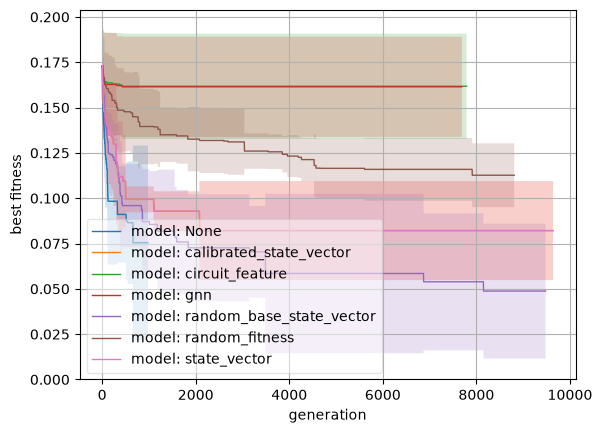

Fitness over explicit evaluations


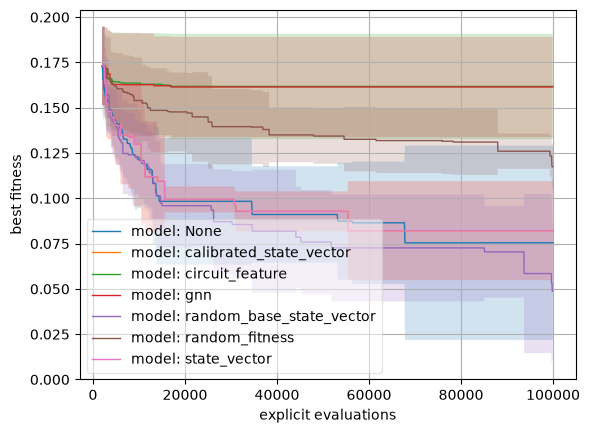

Fitness over time


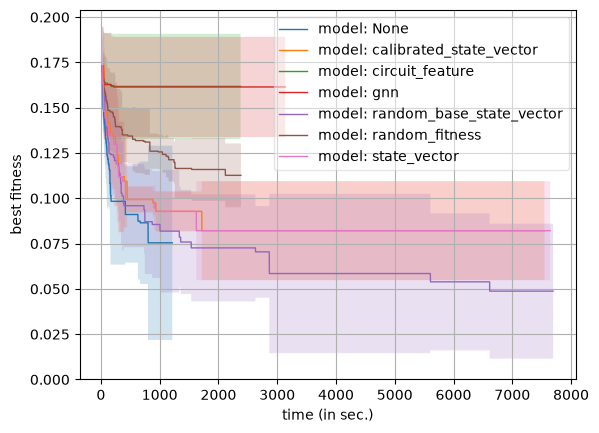

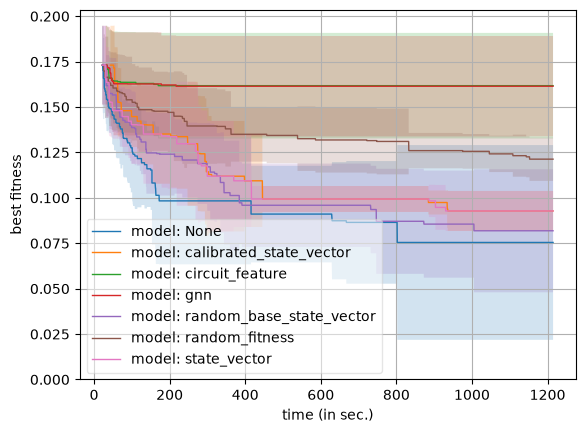

Per seed performance per experiment:

	'model: None' outperformed on 0/6 seeds (0%), tied on 6/6 (100%)
		found a good approximation in 1/6 runs (17%)

	'model: calibrated_state_vector' outperformed on 2/4 seeds (50%), tied on 1/4 (25%)
		found a good approximation in 0/4 runs (0%)

	'model: circuit_feature' outperformed on 0/5 seeds (0%), tied on 0/5 (0%)
		found a good approximation in 0/5 runs (0%)

	'model: gnn' outperformed on 0/5 seeds (0%), tied on 0/5 (0%)
		found a good approximation in 0/5 runs (0%)

	'model: random_base_state_vector' outperformed on 4/4 seeds (100%), tied on 0/4 (0%)
		found a good approximation in 1/4 runs (25%)

	'model: random_fitness' outperformed on 1/5 seeds (20%), tied on 0/5 (0%)
		found a good approximation in 0/5 runs (0%)

	'model: state_vector' outperformed on 2/4 seeds (50%), tied on 1/4 (25%)
		found a good approximation in 0/4 runs (0%)

Evaluations per generation


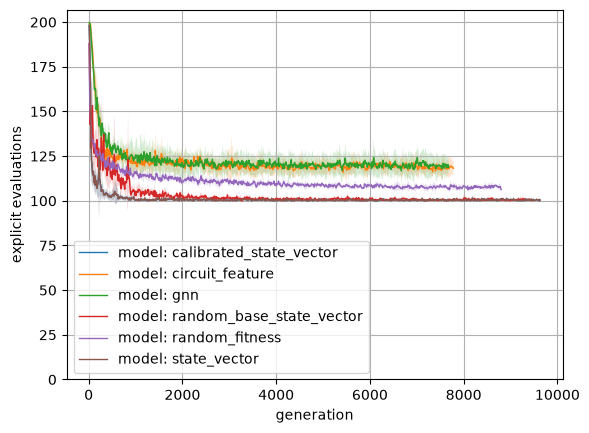

Selection overlap per generation


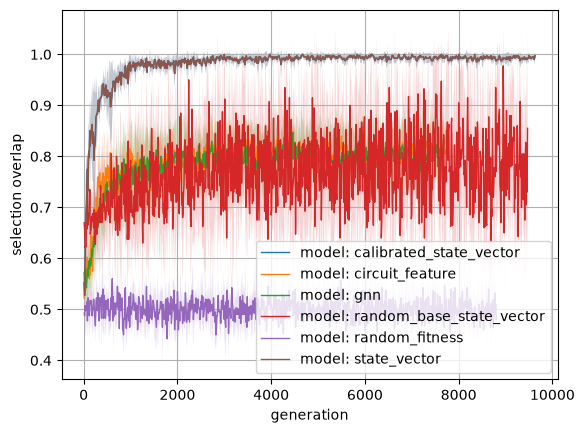

Selection overlap


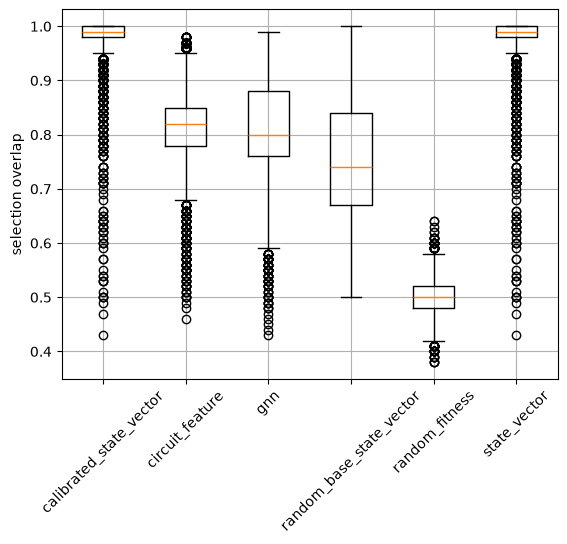

Rank correlations


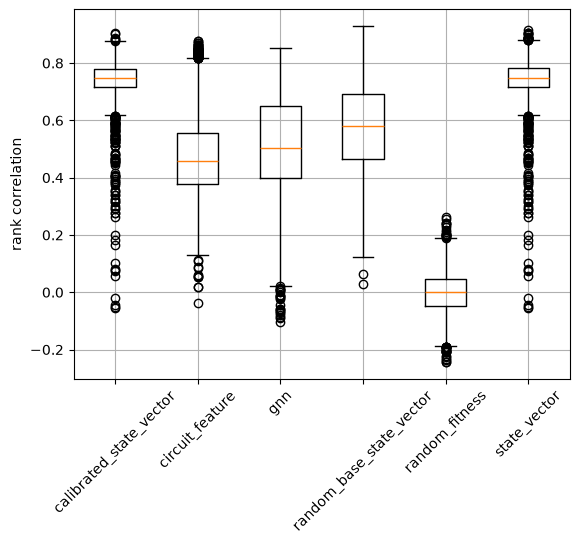

Rank correlations new circuits


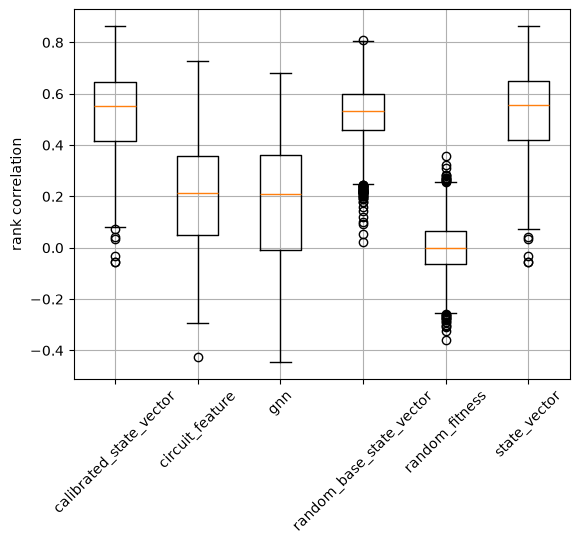

Rank correlations per generation


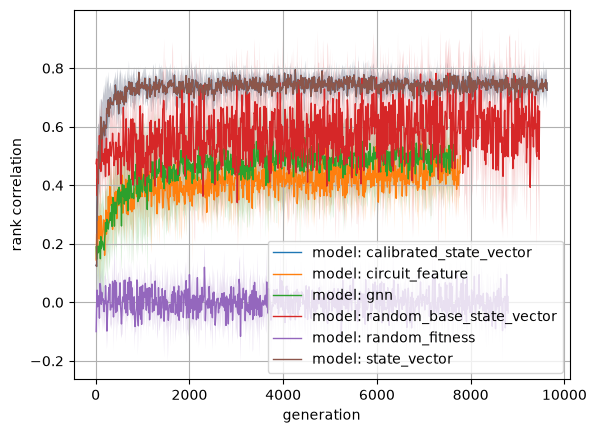

Fitness mse values


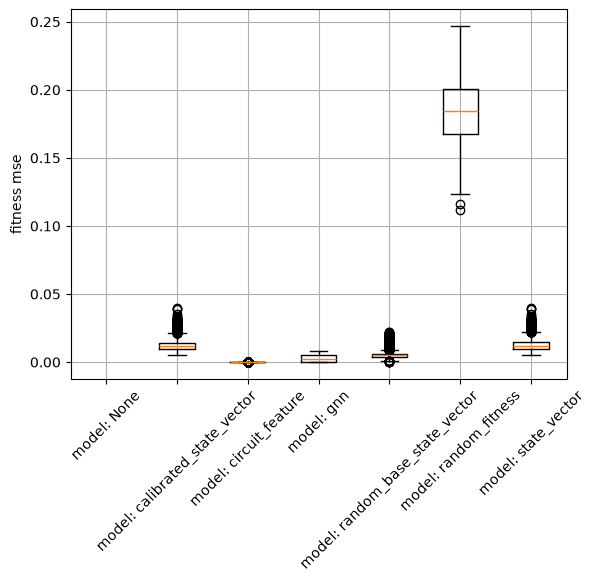

Population diversity


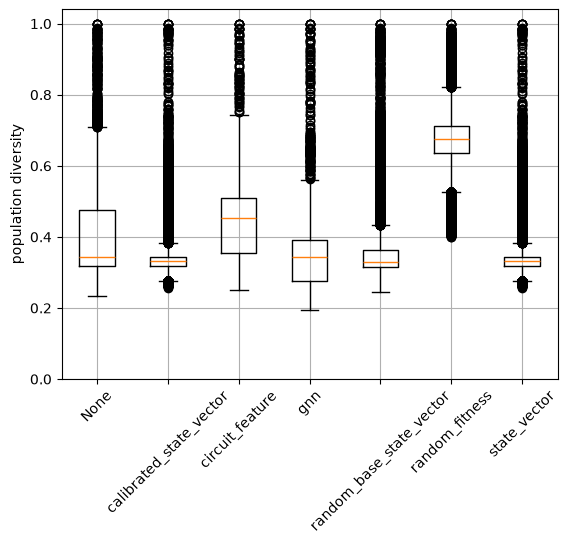

Population diversity over explicit evaluations


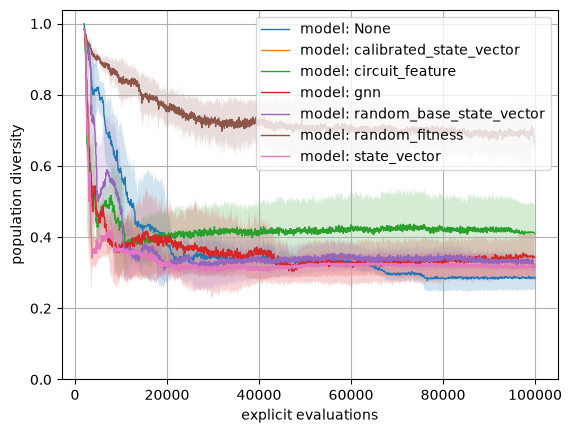

Duration per generation of all generations


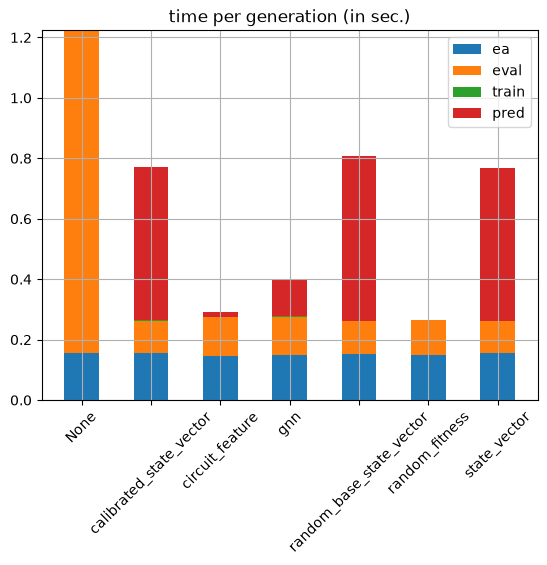

Duration per generation of evaluated generations


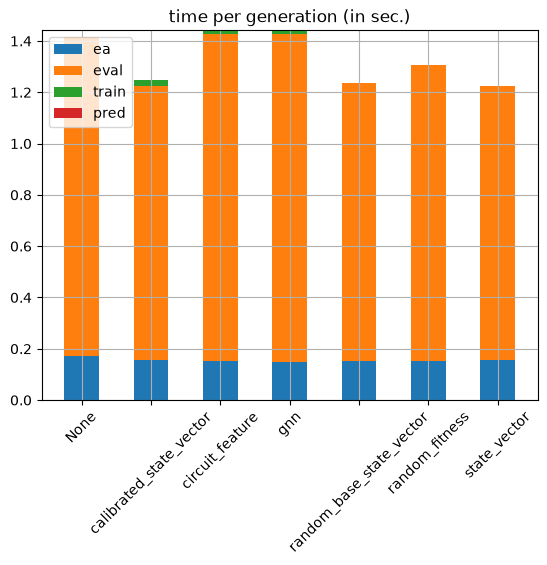

Duration per generation of not evaluated generations


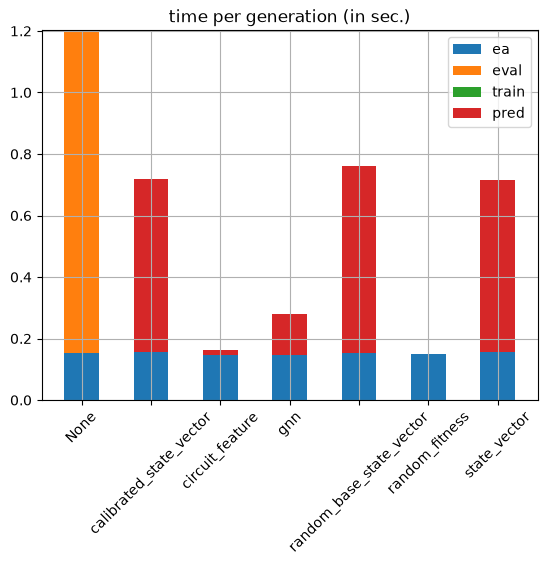

Max memory per generation of evaluated generations


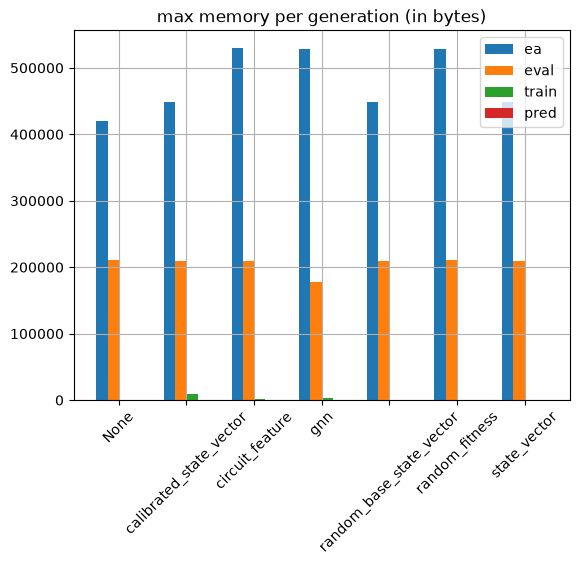

Max memory per generation of not evaluated generations


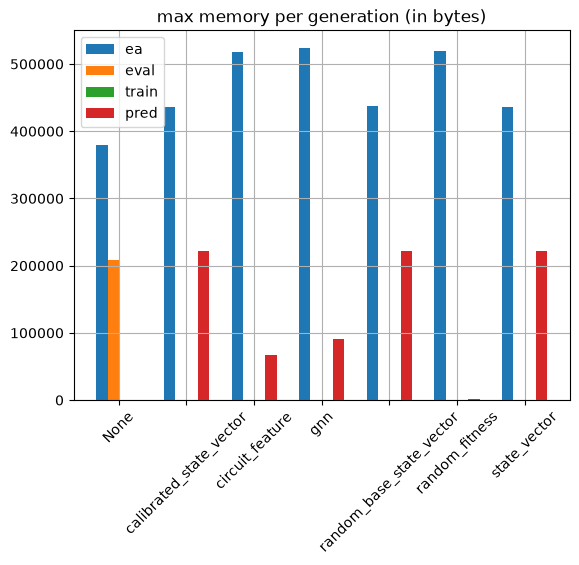


Per seed results of model: None


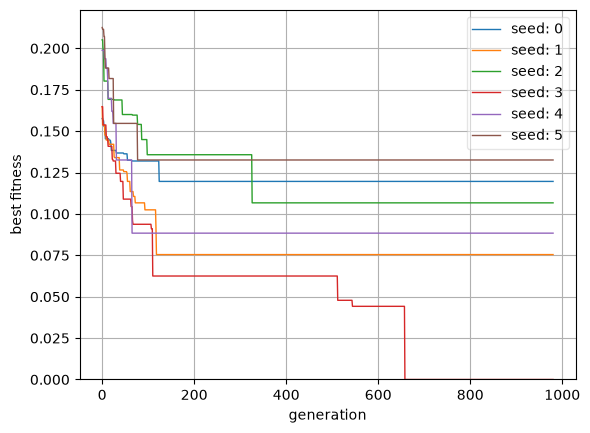


Per seed results of model: calibrated_state_vector


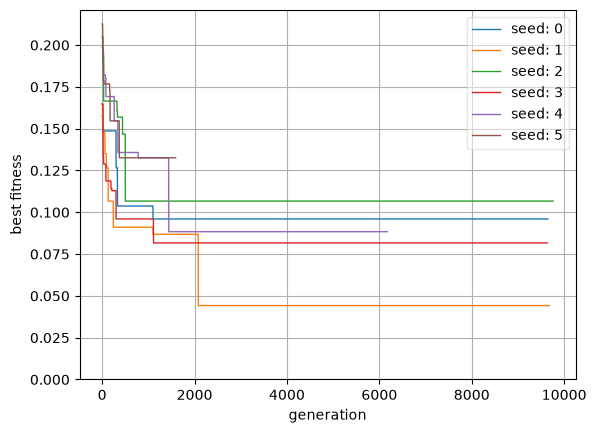


Per seed results of model: circuit_feature


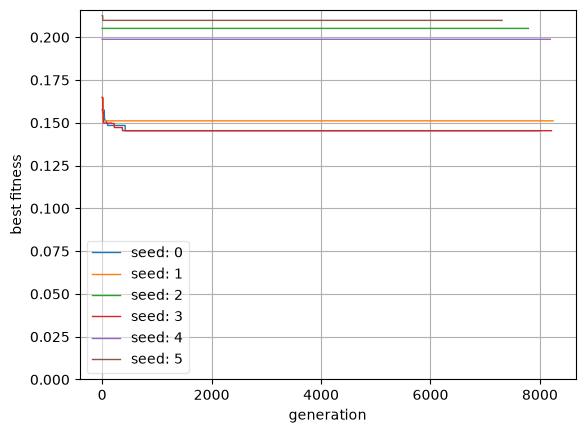


Per seed results of model: gnn


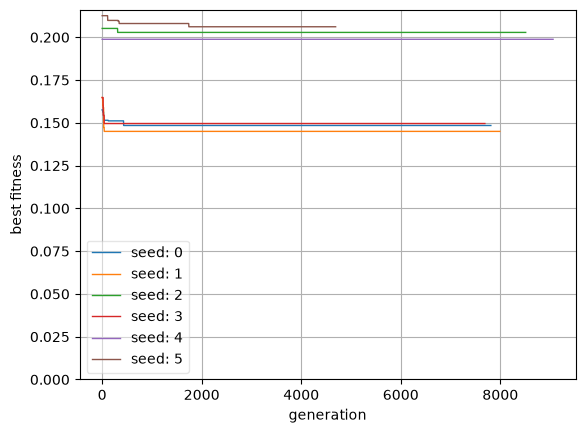


Per seed results of model: random_base_state_vector


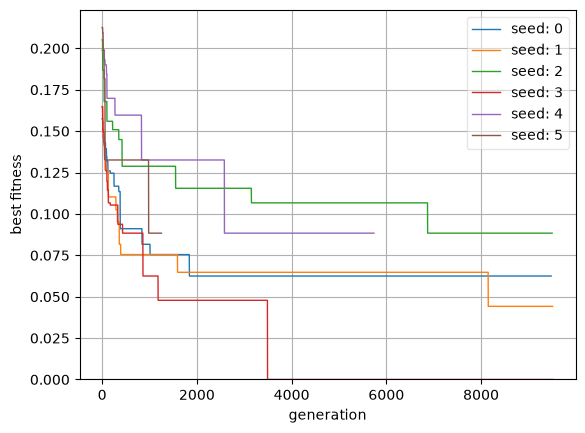


Per seed results of model: random_fitness


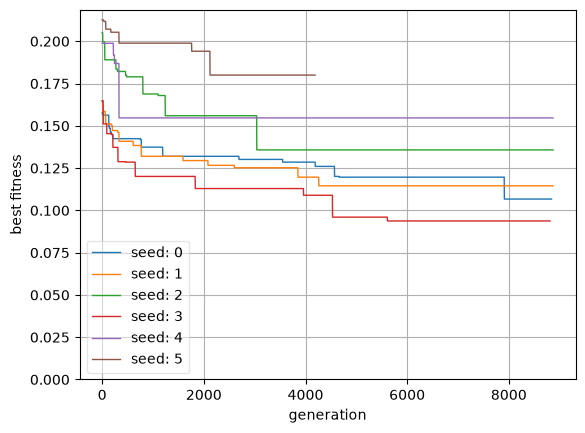


Per seed results of model: state_vector


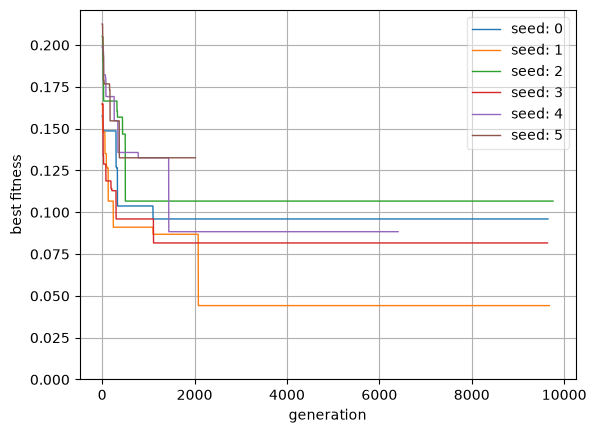


Experiment results for 6 qubits and 18 gates with evaluation every 10. generation
Merging results for seeds [0, 1, 2]
Discarding seed '3'. Only occurred in 4/7 experiments.
Discarding seed '4'. Only occurred in 1/7 experiments.


Experiments:   0%|          | 0/7 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/3 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/3 [00:00<?, ?it/s]

...

Merge by timestamp:   0%|          | 0/3 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/3 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Seed count per setup: 
[(None, 6), ('calibrated_state_vector', 6), ('circuit_feature', 6), ('gnn', 6), ('random_base_state_vector', 6), ('random_fitness', 6), ('state_vector', 6)]
Fitness per generation


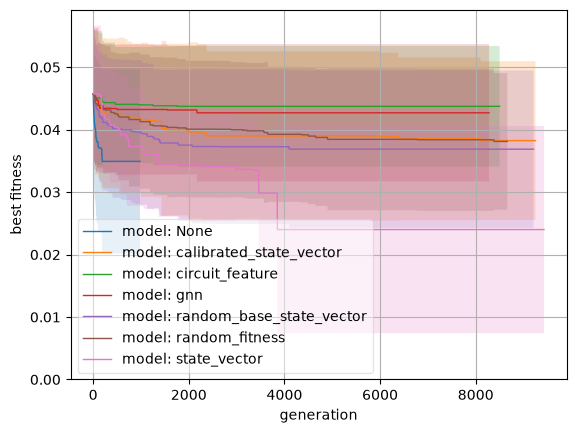

Fitness over explicit evaluations


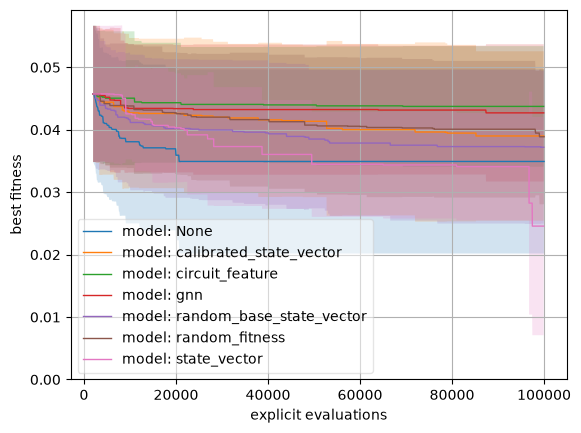

Fitness over time


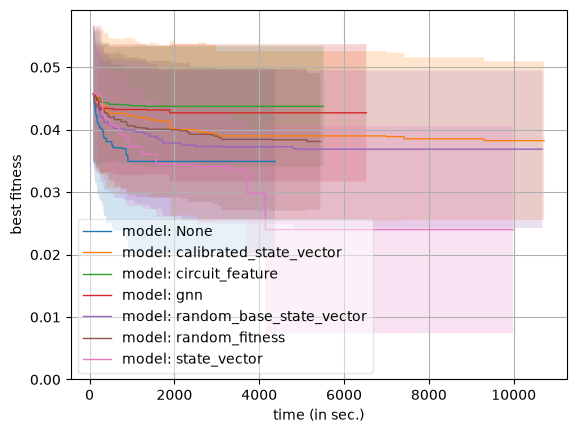

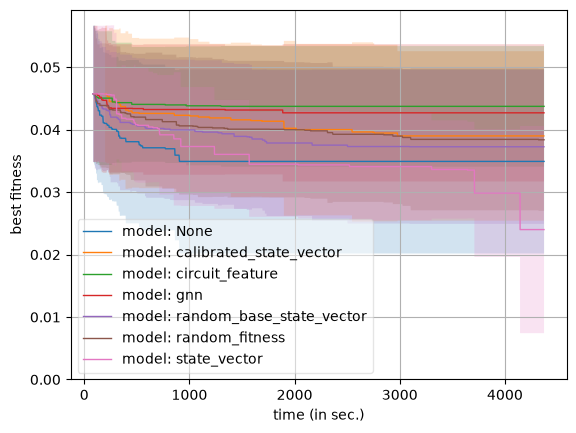

Per seed performance per experiment:

	'model: None' outperformed on 0/5 seeds (0%), tied on 5/5 (100%)
		found a good approximation in 1/5 runs (20%)

	'model: calibrated_state_vector' outperformed on 1/3 seeds (33%), tied on 0/3 (0%)
		found a good approximation in 0/3 runs (0%)

	'model: circuit_feature' outperformed on 0/4 seeds (0%), tied on 0/4 (0%)
		found a good approximation in 0/4 runs (0%)

	'model: gnn' outperformed on 0/4 seeds (0%), tied on 0/4 (0%)
		found a good approximation in 0/4 runs (0%)

	'model: random_base_state_vector' outperformed on 1/3 seeds (33%), tied on 0/3 (0%)
		found a good approximation in 0/3 runs (0%)

	'model: random_fitness' outperformed on 1/4 seeds (25%), tied on 0/4 (0%)
		found a good approximation in 0/4 runs (0%)

	'model: state_vector' outperformed on 2/3 seeds (67%), tied on 0/3 (0%)
		found a good approximation in 1/3 runs (33%)

Evaluations per generation


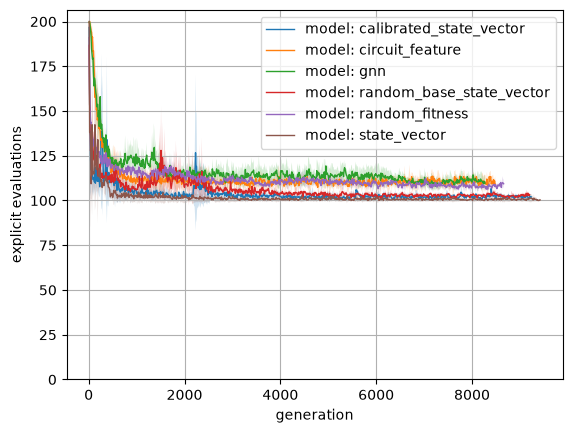

Selection overlap per generation


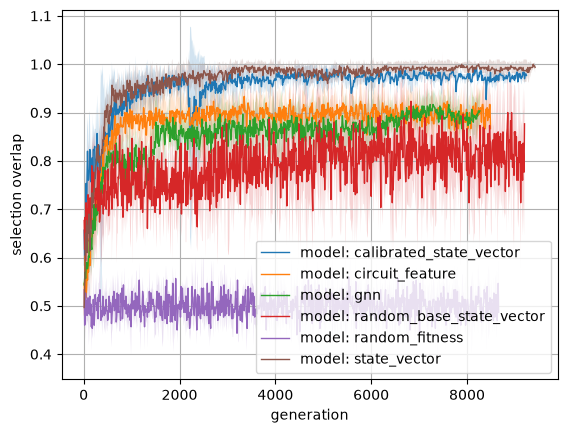

Selection overlap


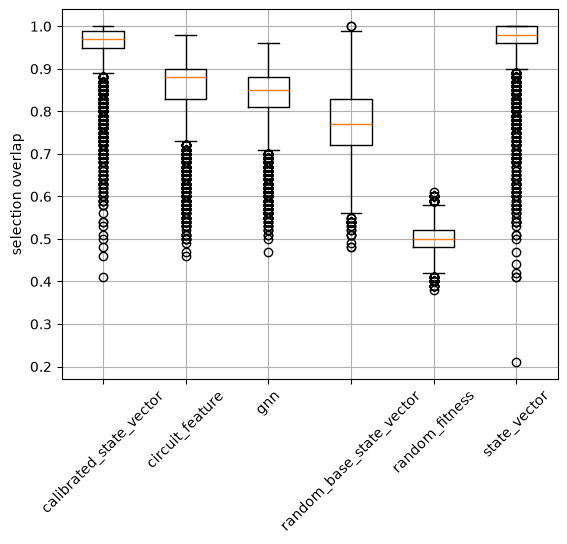

Rank correlations


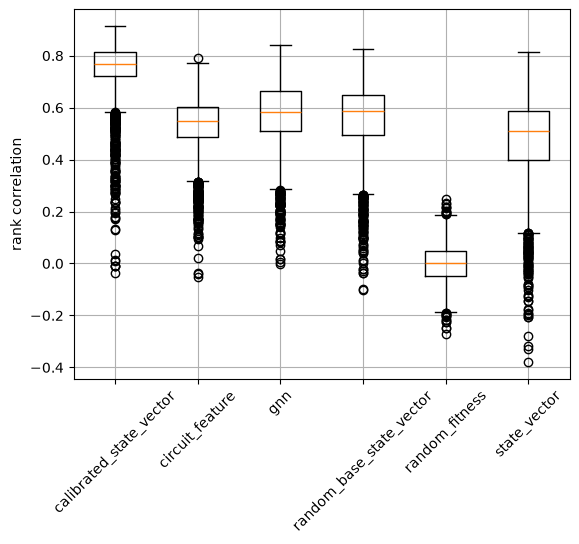

Rank correlations new circuits


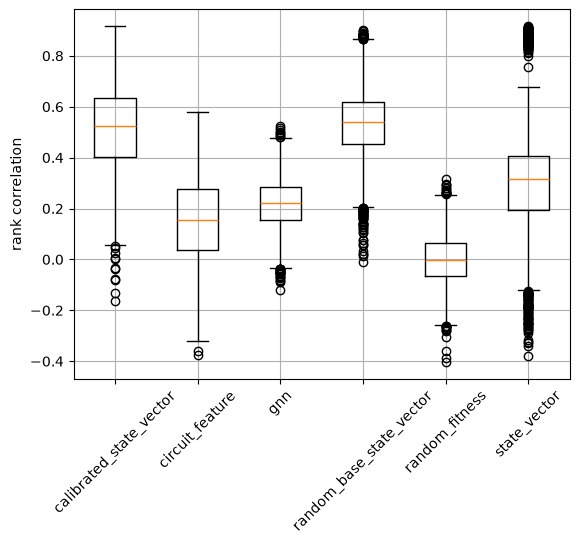

Rank correlations per generation


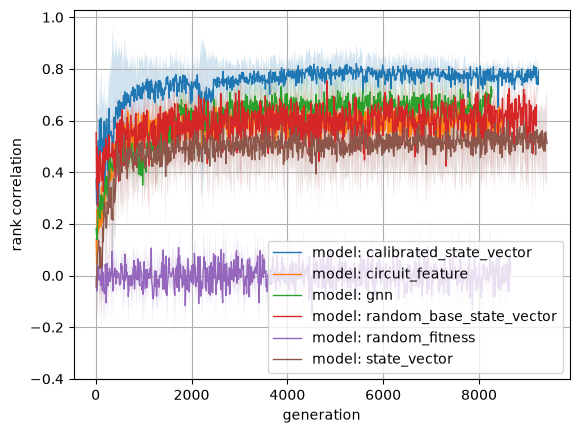

Fitness mse values


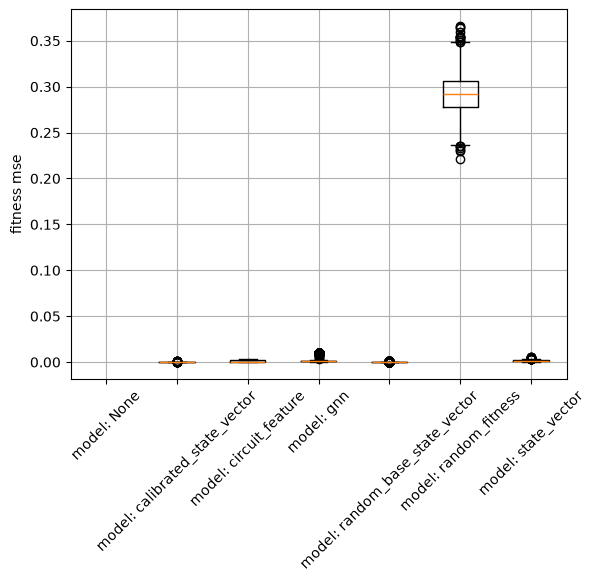

Population diversity


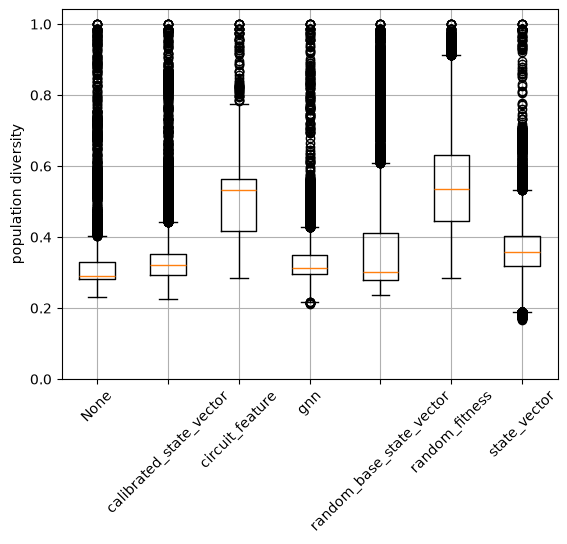

Population diversity over explicit evaluations


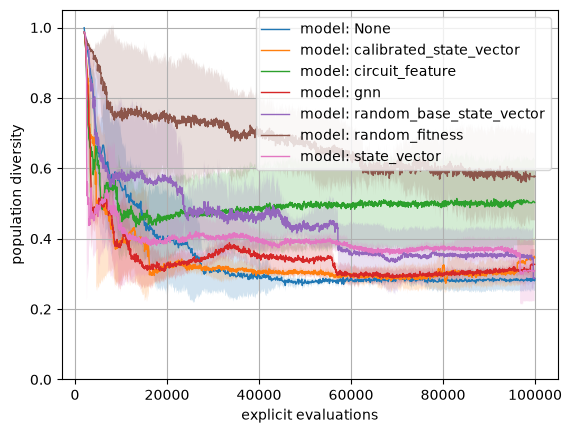

Duration per generation of all generations


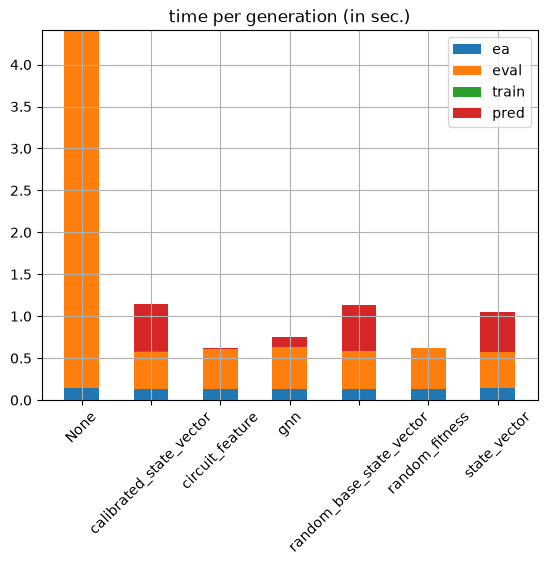

Duration per generation of evaluated generations


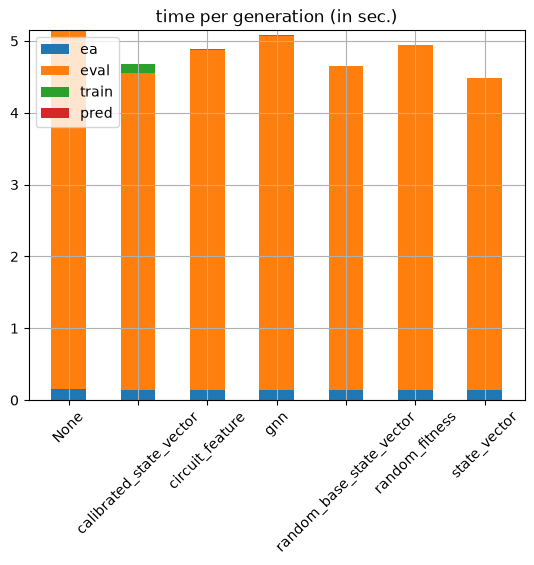

Duration per generation of not evaluated generations


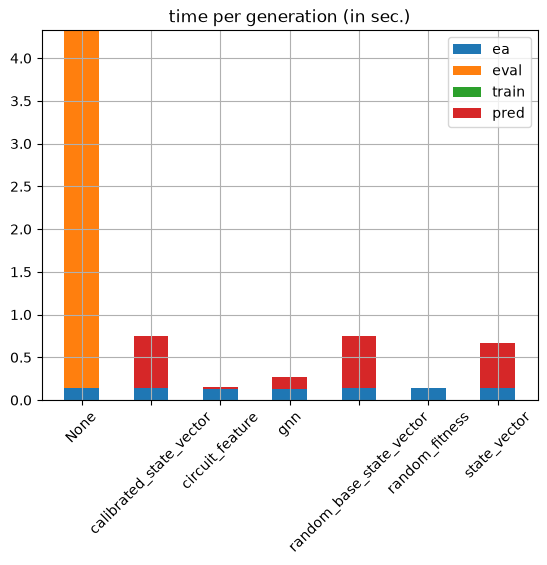

Max memory per generation of evaluated generations


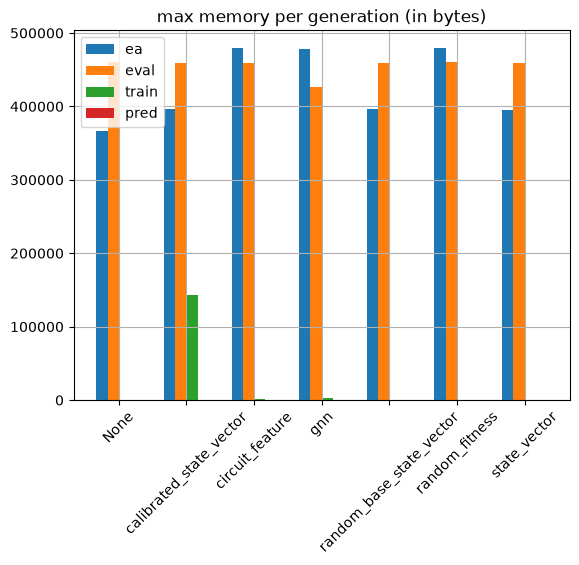

Max memory per generation of not evaluated generations


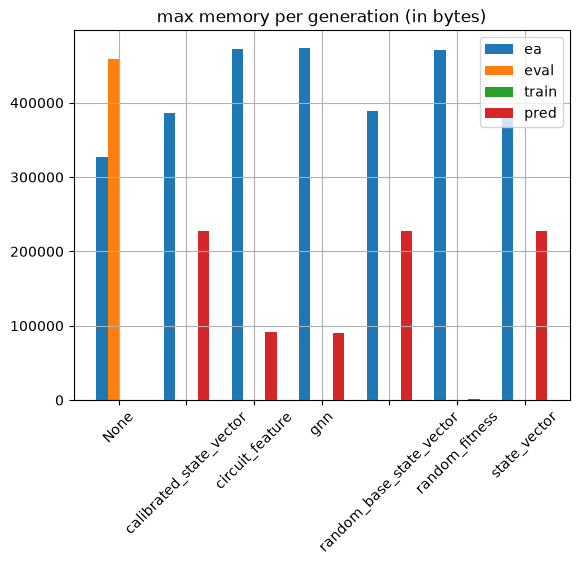


Per seed results of model: None


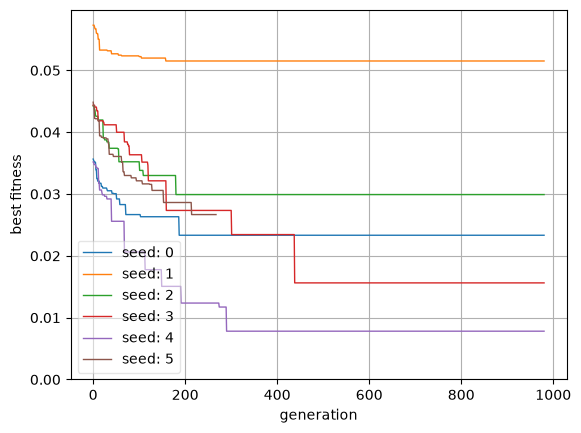


Per seed results of model: calibrated_state_vector


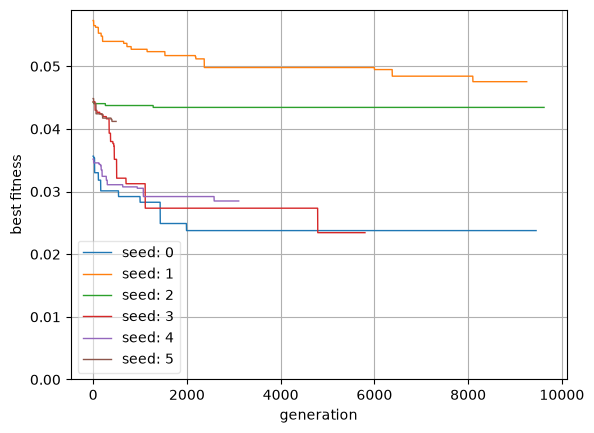


Per seed results of model: circuit_feature


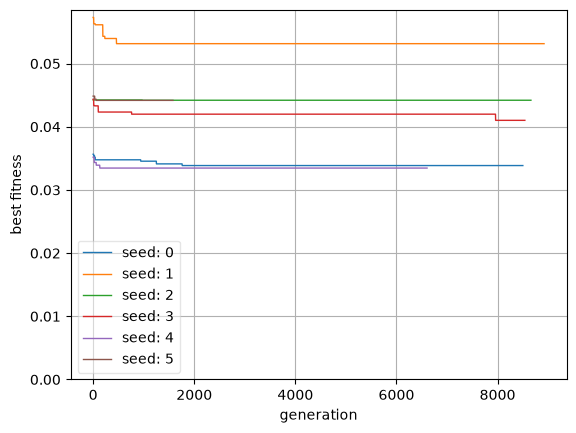


Per seed results of model: gnn


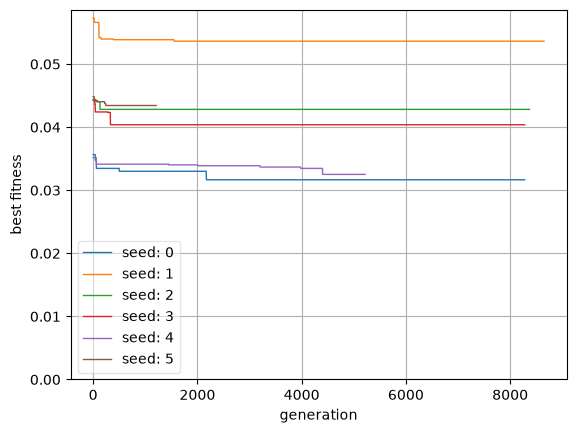


Per seed results of model: random_base_state_vector


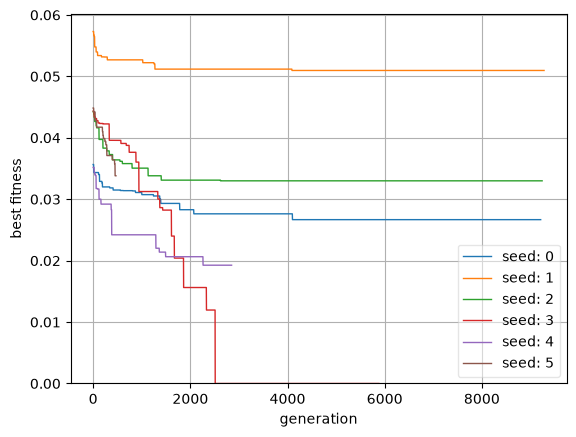


Per seed results of model: random_fitness


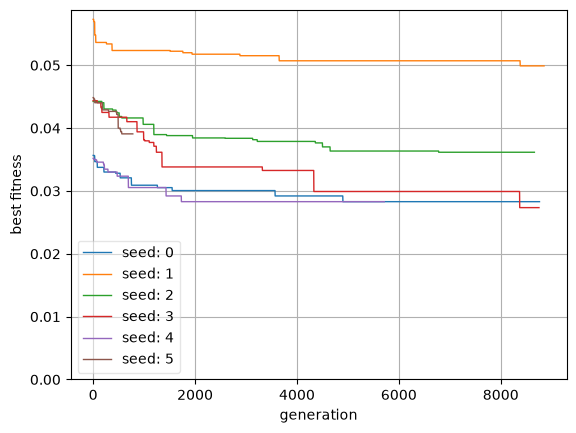


Per seed results of model: state_vector


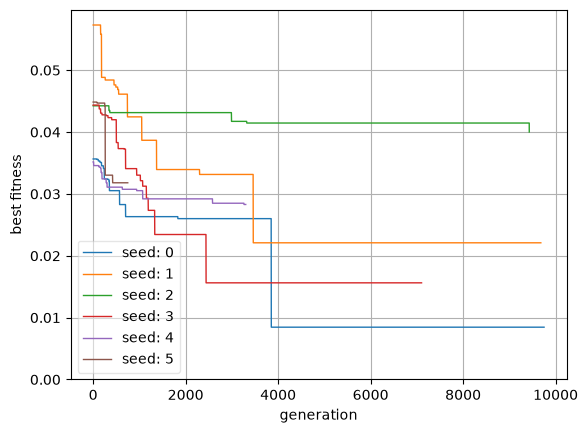


Experiment results for 6 qubits and 30 gates with evaluation every 10. generation
Merging results for seeds []
Discarding seed '0'. Only occurred in 6/7 experiments.
Discarding seed '1'. Only occurred in 4/7 experiments.
Discarding seed '2'. Only occurred in 4/7 experiments.
Discarding seed '3'. Only occurred in 3/7 experiments.
No seed overlap between all experiments.


<Figure size 640x480 with 0 Axes>

In [121]:

qubit_nums = [experiment.qubit_num for experiment in experiments]
qubit_nums = sorted(list(set(qubit_nums)))

gate_counts = [experiment.gate_count for experiment in experiments]
gate_counts = sorted(list(set(gate_counts)))

evaluate_every_values = [
    experiment.evaluate_every for experiment in experiments]
evaluate_every_values = sorted(list(set(evaluate_every_values)))

for qubit_num in qubit_nums:
    for gate_count in gate_counts:

        for evaluate_every in evaluate_every_values:

            rel_experiments = filter_experiments(experiments, filter_params={
                "qubit_num": qubit_num,
                "gate_count": gate_count,
                "evaluate_every": evaluate_every
            })

            if len(rel_experiments) == 0:
                continue

            print()
            printb("=" * 80)
            printb(
                f"Experiment results for {qubit_num} qubits and {gate_count} gates with evaluation every {evaluate_every}. generation")
            printb("=" * 80)

            try:
                merge_seed_runs(rel_experiments, target_evaluations=TARGET_EVALUATIONS,
                                apply_timestamp_merging=APPLY_TIMESTAMP_MERGING, apply_evaluations_merging=APPLY_EVALUATIONS_MERGING)
            except ValueError:
                print(f"No seed overlap between all experiments.")
                continue

            sort_by_model(rel_experiments)

            labels_long = [
                f"model: {experiment.model}" for experiment in rel_experiments]
            labels_short = [
                str(experiment.model) for experiment in rel_experiments]

            print("Seed count per setup: ")
            print([(experiment.model, len(experiment.seeds))
                   for experiment in rel_experiments])

            print("Fitness per generation")
            plot_fitness_per_generation(rel_experiments, labels=labels_long,
                                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_per_generation.png")

            if APPLY_EVALUATIONS_MERGING:
                print("Fitness over explicit evaluations")
                plot_fitness_per_evaluations(
                    rel_experiments, labels=labels_long, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_evaluations.png")

            if APPLY_TIMESTAMP_MERGING:
                print("Fitness over time")
                plot_fitness_per_timestamp(rel_experiments, labels=labels_long,
                                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_time.png")
                plot_fitness_per_timestamp(rel_experiments, labels=labels_long,
                                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_time_cutoff.png",
                                        max_cum_duration=max(rel_experiments[0].data_by_timestamp["cum_duration"]))

            print_per_seed_results(
                rel_experiments, labels=labels_long, baseline=rel_experiments[0], apply_time_cutoff=False
            )

            create_per_seed_latex_table(
                rel_experiments, baseline=rel_experiments[0], target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_table.txt", apply_time_cutoff=False)

            print("Evaluations per generation")
            plot_evaluations_per_generation(
                rel_experiments[1:], labels=labels_long[1:
                                                        ], target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_evaluations_per_generation.png"
            )

            print("Selection overlap per generation")
            plot_selection_overlap_per_generation(
                rel_experiments[1:], labels=labels_long[1:
                                                        ], target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_selection_overlap_per_generation.png"
            )

            print("Selection overlap")
            plot_selection_overlaps(rel_experiments[1:], labels=labels_short[1:],
                                    target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_selection_overlaps.png")

            print("Rank correlations")
            plot_rank_correlations(rel_experiments[1:], labels=labels_short[1:],
                                   target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_rank_correlations.png")

            print("Rank correlations new circuits")
            plot_rank_correlations(rel_experiments[1:], labels=labels_short[1:], only_new_circuits=True,
                                   target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_rank_correlations_new_circuits.png")

            print("Rank correlations per generation")
            plot_rank_correlation_per_generation(
                rel_experiments[1:], labels=labels_long[1:
                                                        ], target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_rank_correlation_per_generation.png"
            )

            print("Fitness mse values")
            plot_fitness_mse_scores(rel_experiments, labels=labels_long,
                                    target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_mse_scores.png")

            # plot_mse_scores_per_generation(
            #     rel_experiments[1:], labels=labels[1:], max_generations=1500
            # )

            # print("Survival rate per generation")
            # plot_survival_rate_per_generation(
            #     rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_survival_rate.png", plot_std=False)

            print("Population diversity")
            plot_population_diversity(
                rel_experiments, labels=labels_short, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_population_diversity.png"
            )

            if APPLY_EVALUATIONS_MERGING:
                print("Population diversity over explicit evaluations")
                plot_population_diversity_per_evaluation(
                    rel_experiments, labels=labels_long, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_population_diversity_over_evaluations.png")


            # print("Durations per generation")
            # plot_duration(rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration.png")

            print("Duration per generation of all generations")
            plot_duration_stacked(rel_experiments, labels=labels_short, relative=False,
                                  target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_all_generations.png")
            print("Duration per generation of evaluated generations")
            plot_duration_stacked(rel_experiments, labels=labels_short, generations="evaluated", relative=False,
                                  target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_evaluated_generations.png")
            print("Duration per generation of not evaluated generations")
            plot_duration_stacked(rel_experiments, labels=labels_short, generations="not_evaluated", relative=False,
                                  target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_not_evaluated_generations.png")

            # print("Max memory per generation")
            # plot_max_memory_per_generation(
            #     rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_max_memory_per_generation.png", max_generations=500
            # )

            print("Max memory per generation of evaluated generations")
            plot_memory(rel_experiments, labels=labels_short, generations="evaluated",
                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_memory_grouped_evaluated_generations.png")
            print("Max memory per generation of not evaluated generations")
            plot_memory(rel_experiments, labels=labels_short, generations="not_evaluated",
                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_memory_grouped_not_evaluated_generations.png")

            for experiment, label in zip(rel_experiments, labels_long):
                print(f"\nPer seed results of {label}")
                plot_fitness_per_seed(
                    experiment=experiment, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_{label}_fitness_per_seed.png")

### Evaluation Rounds Comparison

In [122]:
qubit_nums = [experiment.qubit_num for experiment in experiments]
qubit_nums = sorted(list(set(qubit_nums)))

gate_counts = [experiment.gate_count for experiment in experiments]
gate_counts = sorted(list(set(gate_counts)))

models = [experiment.model for experiment in experiments]
models = list(set(models))

for qubit_num in qubit_nums:
    for gate_count in gate_counts:

        for model in models:

            if model is None:
                continue

            rel_experiments = filter_experiments(experiments, filter_params={
                "qubit_num": qubit_num,
                "gate_count": gate_count,
                "model": model
            })

            if len(rel_experiments) == 0:
                continue

            if len(rel_experiments) == 1:
                continue

            print()
            printb("=" * 80)
            printb(
                f"Experiment results for {qubit_num} qubits and {gate_count} gates with model='{model}'")
            printb("=" * 80)

            try:
                merge_seed_runs(rel_experiments, target_evaluations=TARGET_EVALUATIONS,
                                apply_timestamp_merging=APPLY_TIMESTAMP_MERGING, apply_evaluations_merging=APPLY_EVALUATIONS_MERGING)
            except ValueError:
                print(f"No seed overlap between all experiments.")
                continue

            rel_experiments.sort(key=lambda item: item.evaluate_every)

            labels_long = [
                f"every {experiment.evaluate_every} generations" for experiment in rel_experiments]
            labels_short = [
                f"every {experiment.evaluate_every} gen." for experiment in rel_experiments]

            print("Seed count per setup: ")
            print([(experiment.model, len(experiment.seeds))
                   for experiment in rel_experiments])

            if APPLY_EVALUATIONS_MERGING:
                print("Fitness over explicit evaluations")
                plot_fitness_per_evaluations(
                    rel_experiments, labels=labels_long, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_evaluations.png")

            if APPLY_TIMESTAMP_MERGING:
                print("Fitness over time")
                plot_fitness_per_timestamp(rel_experiments, labels=labels_long,
                                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_time_cutoff.png",
                                        max_cum_duration=max(rel_experiments[0].data_by_timestamp["cum_duration"]))

            print("Selection overlap")
            plot_selection_overlaps(rel_experiments, labels=labels_short,
                                    target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_selection_overlaps.png")

            print("Rank correlations")
            plot_rank_correlations(rel_experiments, labels=labels_short,
                                   target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_rank_correlations.png")

            # print("Duration per generation of all generations")
            # plot_duration_stacked(rel_experiments, labels=labels, relative=False,
            #                       target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_all_generations.png")
            # print("Duration per generation of evaluated generations")
            # plot_duration_stacked(rel_experiments, labels=labels, generations="evaluated", relative=False,
            #                       target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_evaluated_generations.png")
            # print("Duration per generation of not evaluated generations")
            # plot_duration_stacked(rel_experiments, labels=labels, generations="not_evaluated", relative=False,
            #                       target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_not_evaluated_generations.png")

            # print("Max memory per generation of evaluated generations")
            # plot_memory(rel_experiments, labels, generations="evaluated",
            #             target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_memory_grouped_evaluated_generations.png")
            # print("Max memory per generation of not evaluated generations")
            # plot_memory(rel_experiments, labels, generations="not_evaluated",
            #             target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_memory_grouped_not_evaluated_generations.png")